# Supplementary: Checking spe-1 patch recordings for a stimulation artifact

**Ashley's comment:** the spe-1 dataset is described as spontaneous activity, but we can't formally rule out that the experimenter delivered stimulation at some points to drive low-firing neurons. Her suggestion for what to look for: *"I think you would see this as a very slight shift in membrane potential unless they had balanced the bridge absolutely perfectly ... you might also see tiny capacitance transients."*

**What this notebook does:** exactly that, and nothing more - for every spe-1 cell, using the **raw, unfiltered** patch recording (not the bandpass-filtered version used elsewhere in the paper, since filtering can hide a slow baseline shift):

1. Plot the resting baseline level across the whole recording, for every cell at a glance - a real shift would show up as a step to a new sustained level.
2. Zoom into a handful of raw-trace snippets for any cell of interest, to look by eye for brief transient blips.

No spike detection, no statistics, no automatic classification - just look at the trace.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../datasets/spe-1/spe1_helper_modules/')
import config

RAW_PATCH_DIR = os.path.join(config.SPE1_DATA_ROOT, 'raw_patch_recordings')

def load_raw_patch(cell_num):
    """Load a cell's raw, unfiltered patch recording (float64, in the units it was recorded in)."""
    fs = config.DICT_PATCH_FS[cell_num]
    trace = np.fromfile(os.path.join(RAW_PATCH_DIR, f'c{cell_num}_patch_ch1.bin'), dtype='float64')
    return trace, fs

## 1. Does the baseline level shift anywhere during the recording?

For each cell: split the raw recording into 1-second chunks and take the median voltage in each chunk (the median is barely affected by the handful of tall, brief spikes in each chunk, so this line tracks the *resting* level, not the spikes). A steady, if noisy, flat line means no shift. A step up or down to a new sustained level would be exactly the kind of "slight shift in membrane potential" Ashley described.

In [2]:
cell_nums = sorted(int(c[1:]) for c in config.CELL_IDS)

baselines = {}
for cell_num in cell_nums:
    trace, fs = load_raw_patch(cell_num)
    bin_samples = int(1.0 * fs)  # 1-second bins
    n_bins = len(trace) // bin_samples
    chunks = trace[:n_bins * bin_samples].reshape(n_bins, bin_samples)
    baseline = np.median(chunks, axis=1)
    t_min = np.arange(n_bins) / 60.0  # minutes
    baselines[cell_num] = (t_min, baseline)

print(f'Computed baseline traces for {len(baselines)} cells.')

Computed baseline traces for 43 cells.


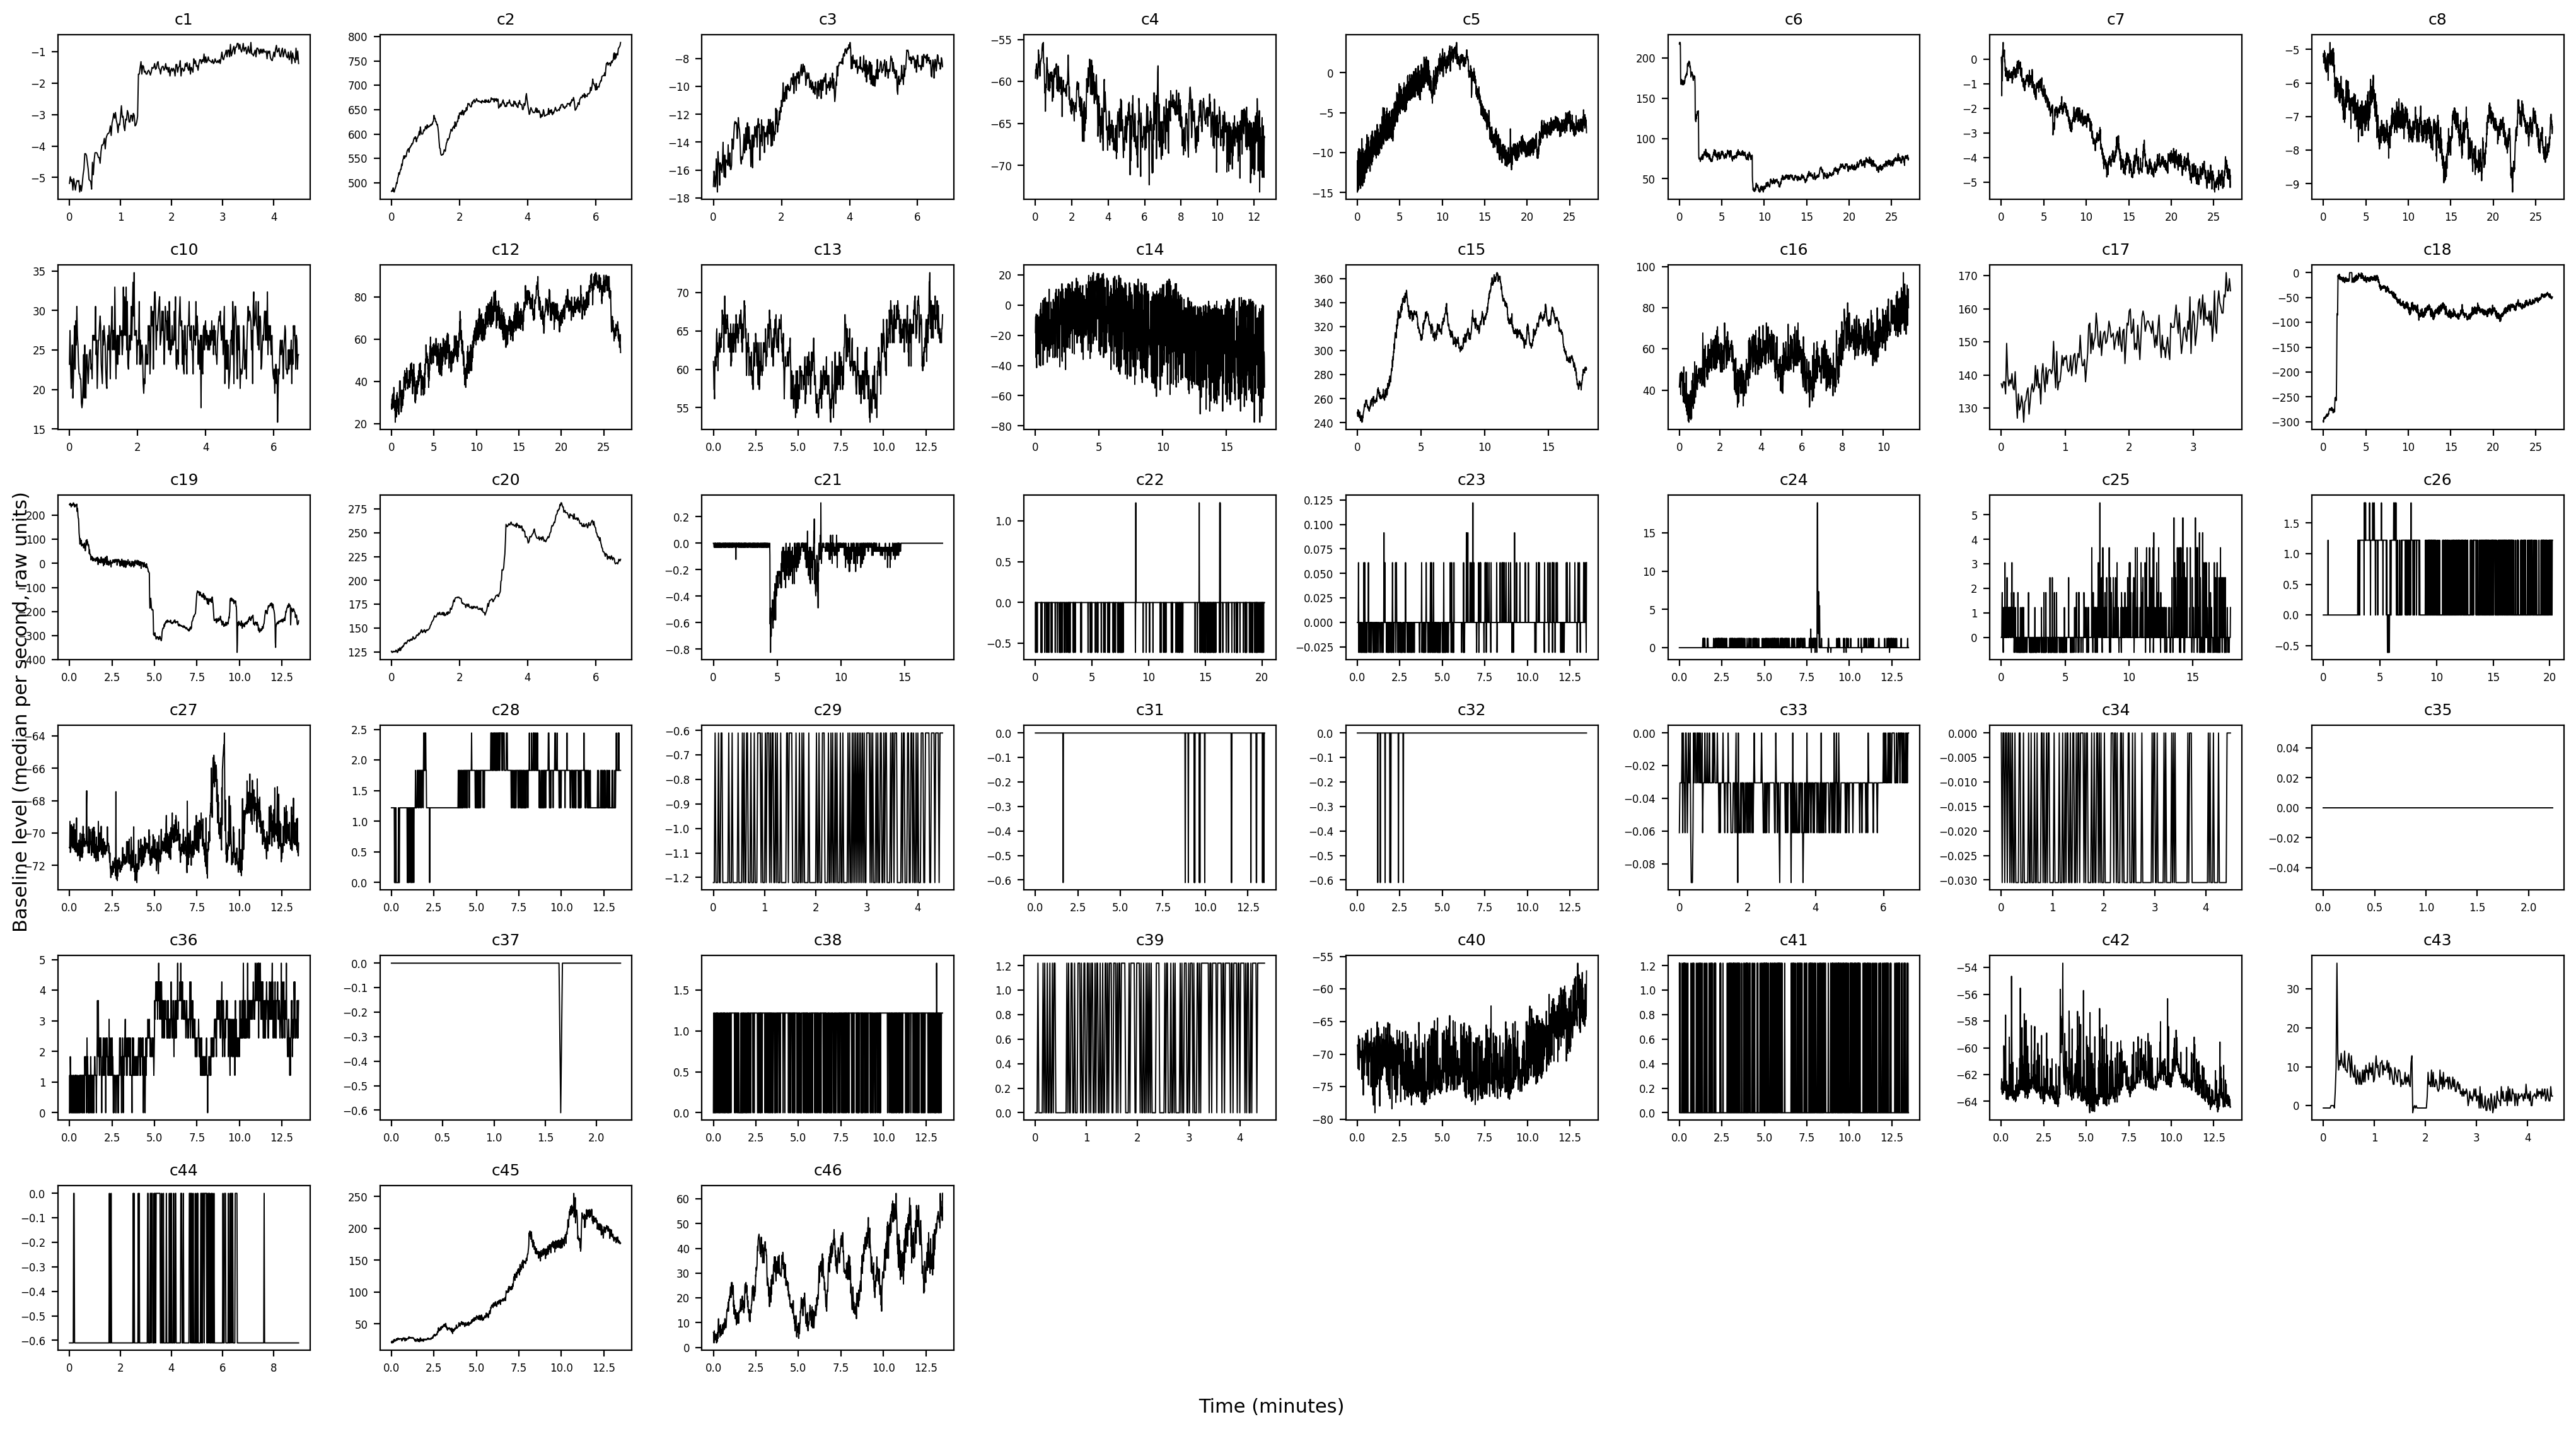

In [3]:
n = len(cell_nums)
ncols = 8
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 1.9))
axes = axes.flatten()

for ax, cell_num in zip(axes, cell_nums):
    t_min, baseline = baselines[cell_num]
    ax.plot(t_min, baseline, color='black', lw=0.7)
    ax.set_title(f'c{cell_num}', fontsize=9)
    ax.tick_params(labelsize=6)

for ax in axes[n:]:
    ax.axis('off')

fig.supxlabel('Time (minutes)', fontsize=11)
fig.supylabel('Baseline level (median per second, raw units)', fontsize=11)
plt.tight_layout()
plt.show()

### Finding jumps automatically, instead of scanning 43 plots by eye

For each cell's baseline line above: take the step-to-step change from one second to the next, everywhere in the recording. Most of those steps are just normal wiggle. Rather than only looking at the single biggest step per cell, take up to its 3 largest steps, skipping any candidate within 30 seconds of a bigger one already picked (a real ramp or step shows up as several large one-second changes in a row, so without this a single event would get counted as 2-3 separate ones). Compare each to that cell's typical step size (the median of all its steps): `jump_ratio = jump size / typical step`. A jump that's, say, 20x a cell's normal wiggle has something real going on; one that's only 2-3x normal is just noise. Every cell's single biggest jump is kept regardless of ratio (so the full 43-cell picture below matches before); its 2nd and 3rd largest jumps are only kept if they clear a 5x ratio on their own, so the table isn't padded with ordinary noise. Sorted by rank within each cell, biggest first.

In [4]:
import pandas as pd

TOP_N = 3        # check up to this many of each cell's largest jumps, not just the single biggest
MIN_SEP_S = 30   # candidate jumps closer together than this count as one event, not two
RATIO_THRESH = 5 # a cell's 2nd/3rd jump only counts if it clears this ratio on its own

rows = []
for cell_num in cell_nums:
    t_min, baseline = baselines[cell_num]
    steps = np.abs(np.diff(baseline))
    typical_step = np.median(steps)
    times_s = t_min[:-1] * 60

    order = np.argsort(steps)[::-1]
    picked = []
    for idx in order:
        if len(picked) >= TOP_N:
            break
        if any(abs(times_s[idx] - times_s[p]) < MIN_SEP_S for p in picked):
            continue
        picked.append(idx)

    for rank, idx in enumerate(picked):
        jump_size = steps[idx]
        jump_ratio = jump_size / (typical_step + 1e-12)
        if rank > 0 and jump_ratio <= RATIO_THRESH:
            continue
        rows.append({
            'cell_id': f'c{cell_num}',
            'rank': rank,
            'biggest_jump': jump_size,
            'typical_step': typical_step,
            'jump_ratio': jump_ratio,
            'jump_at_minute': times_s[idx] / 60,
        })

jump_df = pd.DataFrame(rows).sort_values(['cell_id', 'rank']).reset_index(drop=True)
jump_df.round(3)

,cell_id,rank,biggest_jump,typical_step,jump_ratio,jump_at_minute
0,c1,0,1.343,0.122,11.00,1.333
1,c1,1,0.854,0.122,7.00,0.433
2,c10,0,9.766,2.441,4.00,5.383
3,c12,0,13.428,2.441,5.50,10.333
4,c12,1,12.817,2.441,5.25,11.717
...,...,...,...,...,...,...
90,c7,1,0.793,0.122,6.50,25.583
91,c7,2,0.793,0.122,6.50,11.683
92,c8,0,1.160,0.153,7.60,5.283
93,c8,1,0.885,0.153,5.80,2.333


### Looking at every flagged jump, not just the biggest one per cell

For every cell where `typical_step` was a real (non-zero) number, zoom into +/-5 seconds of the raw trace around each of its flagged jump times, its single biggest jump plus any 2nd/3rd jump that cleared the 5x ratio above, the same way as the manual check earlier, just done for all of them instead of 3. Cells where `typical_step` was 0 (listed at the top of the earlier table) are skipped here, their ratio was a divide-by-near-zero artifact, not a real measurement, so there's nothing meaningful to zoom into for those from this method.

57 flagged jumps across 29 cells with a meaningful (non-degenerate) jump_ratio; zooming into each flagged jump time below.


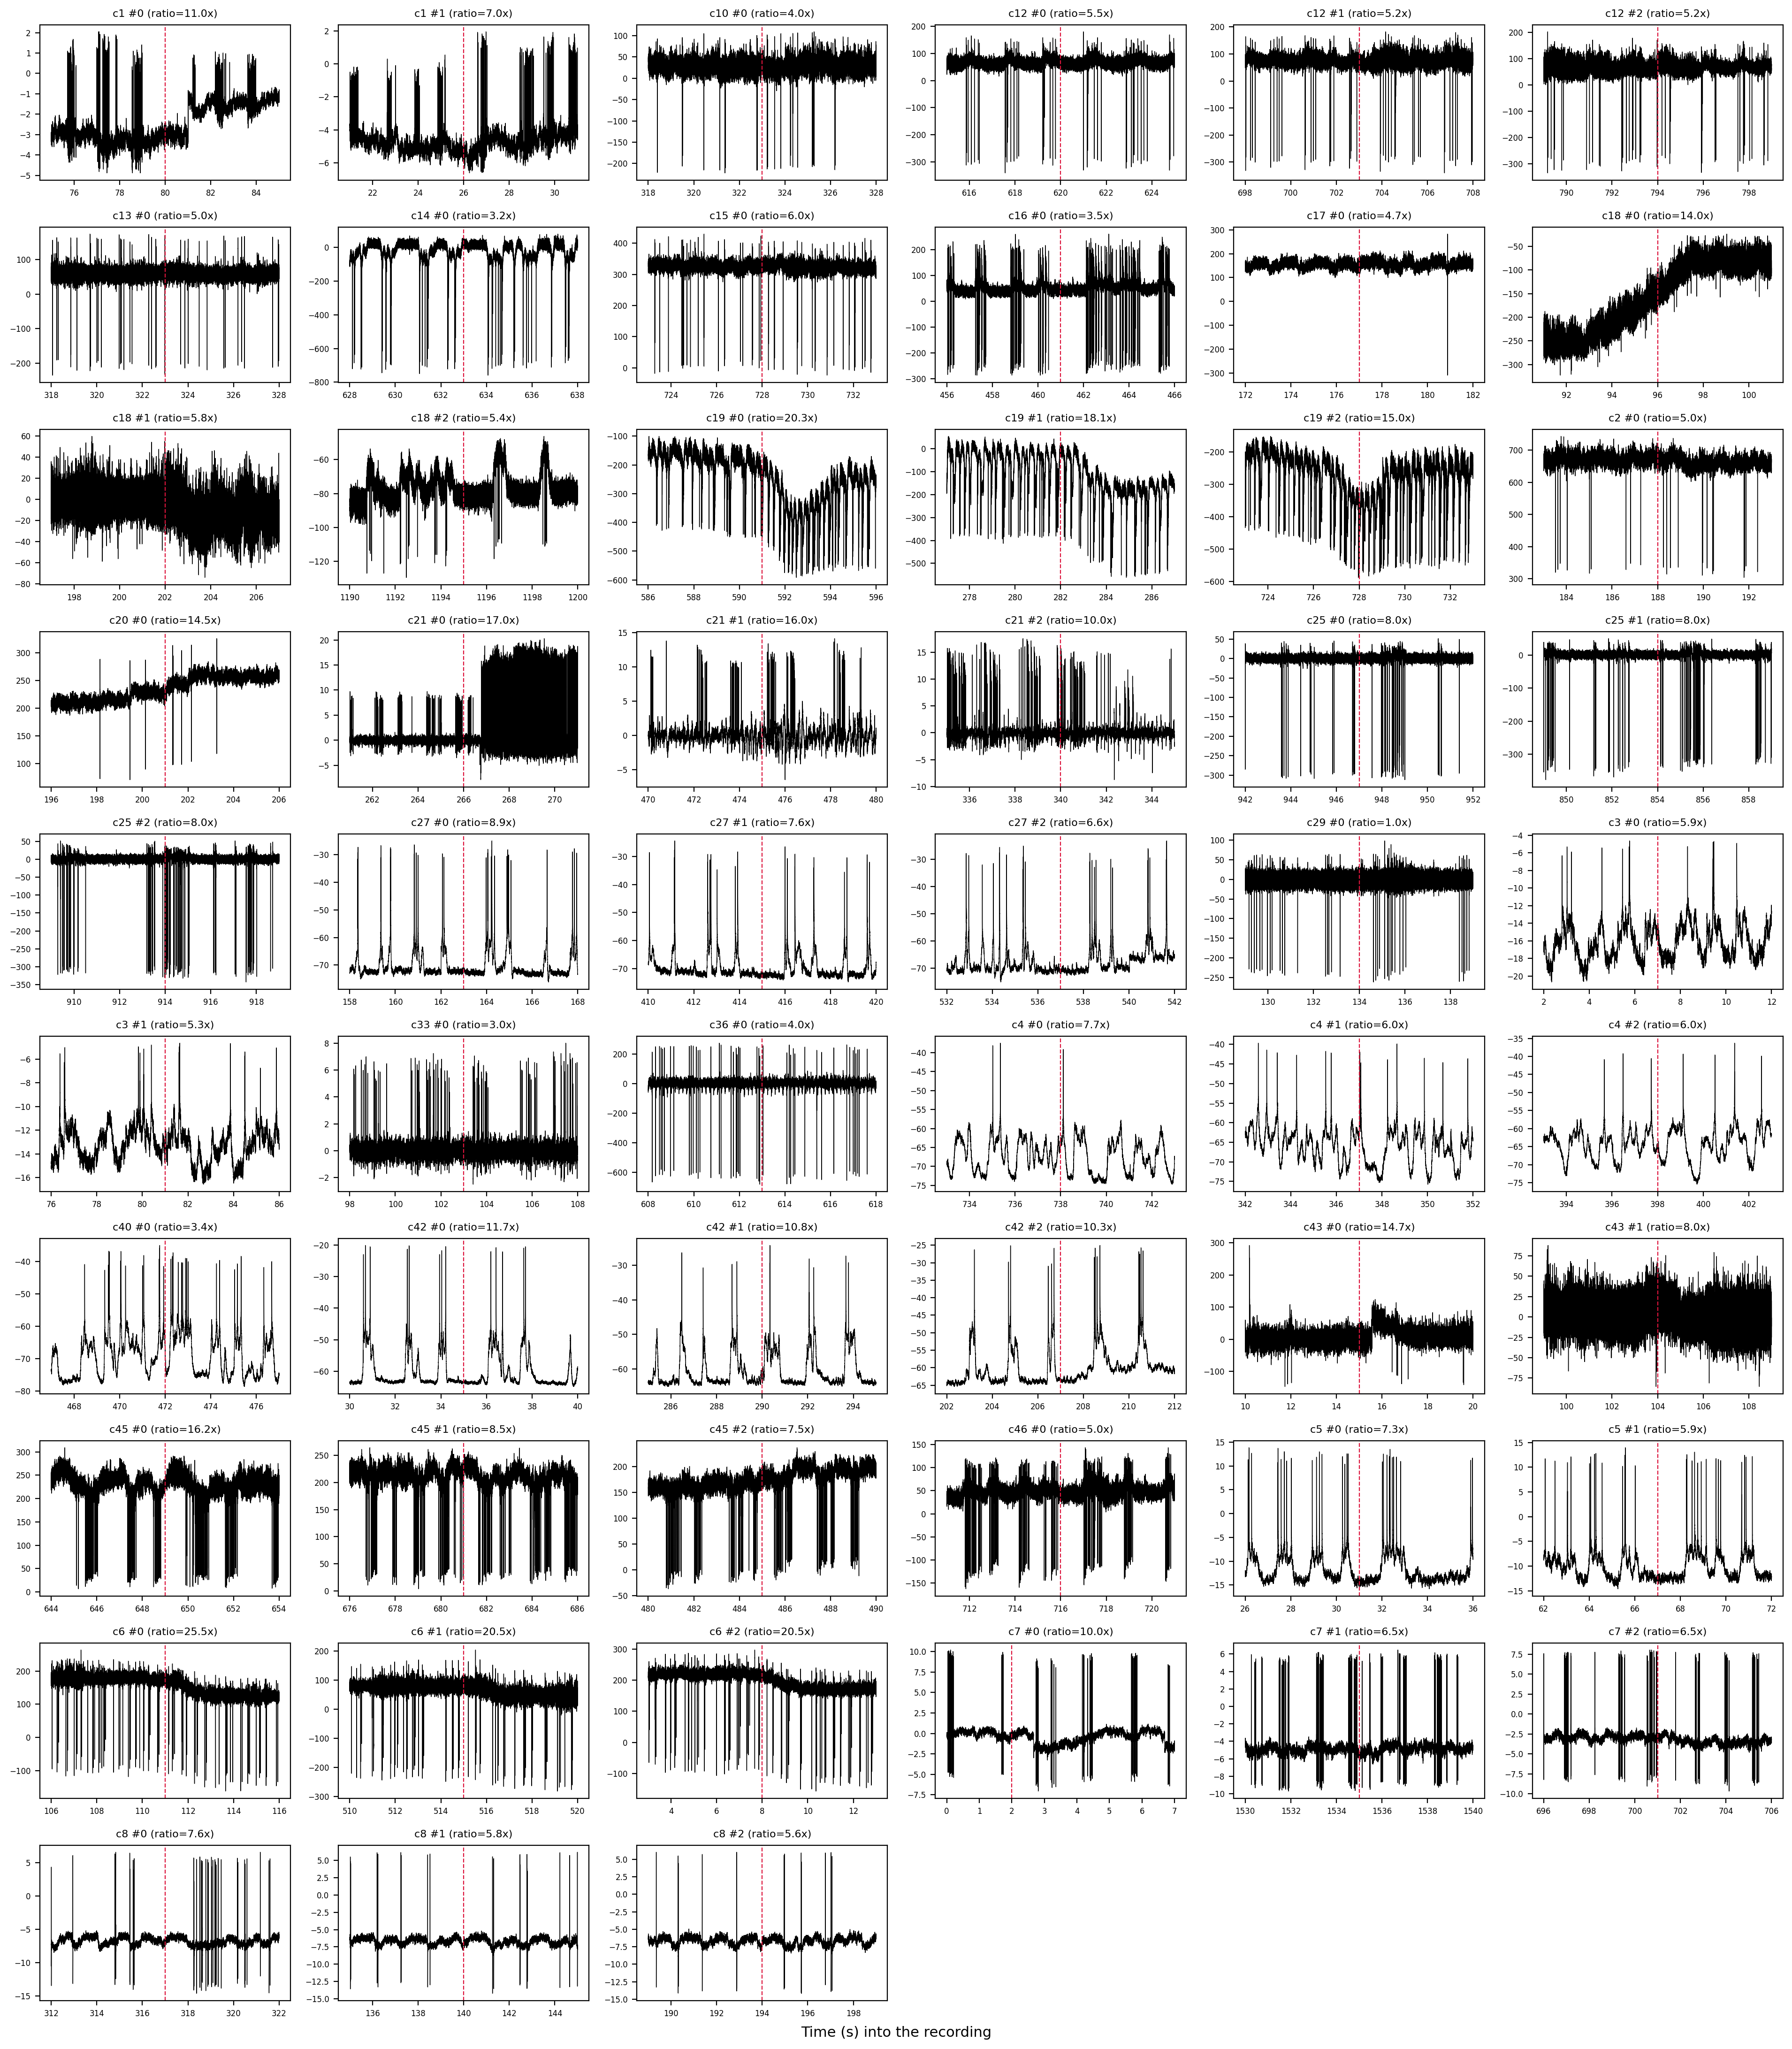

In [5]:
valid_jumps = jump_df[jump_df['typical_step'] > 1e-9].reset_index(drop=True)
print(f'{len(valid_jumps)} flagged jumps across {valid_jumps["cell_id"].nunique()} cells with a meaningful '
      f'(non-degenerate) jump_ratio; zooming into each flagged jump time below.')

ncols = 6
nrows = int(np.ceil(len(valid_jumps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.2))
axes = axes.flatten()

for ax, row in zip(axes, valid_jumps.itertuples()):
    cell_num = int(row.cell_id[1:])
    fs = config.DICT_PATCH_FS[cell_num]
    trace, _ = load_raw_patch(cell_num)
    t_center = row.jump_at_minute * 60
    i0 = max(0, int((t_center - 5) * fs))
    i1 = min(len(trace), int((t_center + 5) * fs))
    seg = trace[i0:i1]
    t = (np.arange(len(seg)) + i0) / fs
    ax.plot(t, seg, color='black', lw=0.5)
    ax.axvline(t_center, color='crimson', ls='--', lw=0.8)
    ax.set_title(f'{row.cell_id} #{row.rank} (ratio={row.jump_ratio:.1f}x)', fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes[len(valid_jumps):]:
    ax.axis('off')

fig.supxlabel('Time (s) into the recording', fontsize=11)
plt.tight_layout()
plt.show()

### Cells with a visible change at their flagged jump(s)

Of the cells above, most show nothing notable, the flagged "jump" was just an ordinary large spike or burst. The same 6 cells as before show a real, visible change: c6, c18, c19, c20, c21, c43. Checking each cell's 2nd/3rd largest jump on top of its biggest didn't add a 7th cell to that list. For c6, c18, c19, and c21, the extra flagged points turned out to be the same already-flagged transition still unfolding over the next minute or two (a ramp or a gradual rate change shows up as more than one large step in a row), not a second, independent event elsewhere in the recording. For every other cell with an extra flagged jump, it's ordinary bursty spiking with no visible sustained change, same as the majority above. Shown larger below, with what kind of change it looks like at each cell's earliest (biggest) flagged point. This doesn't say *why* it happens (real physiology and an imperfect current step can look similar here), it's just an honest visual flag of where something changes.

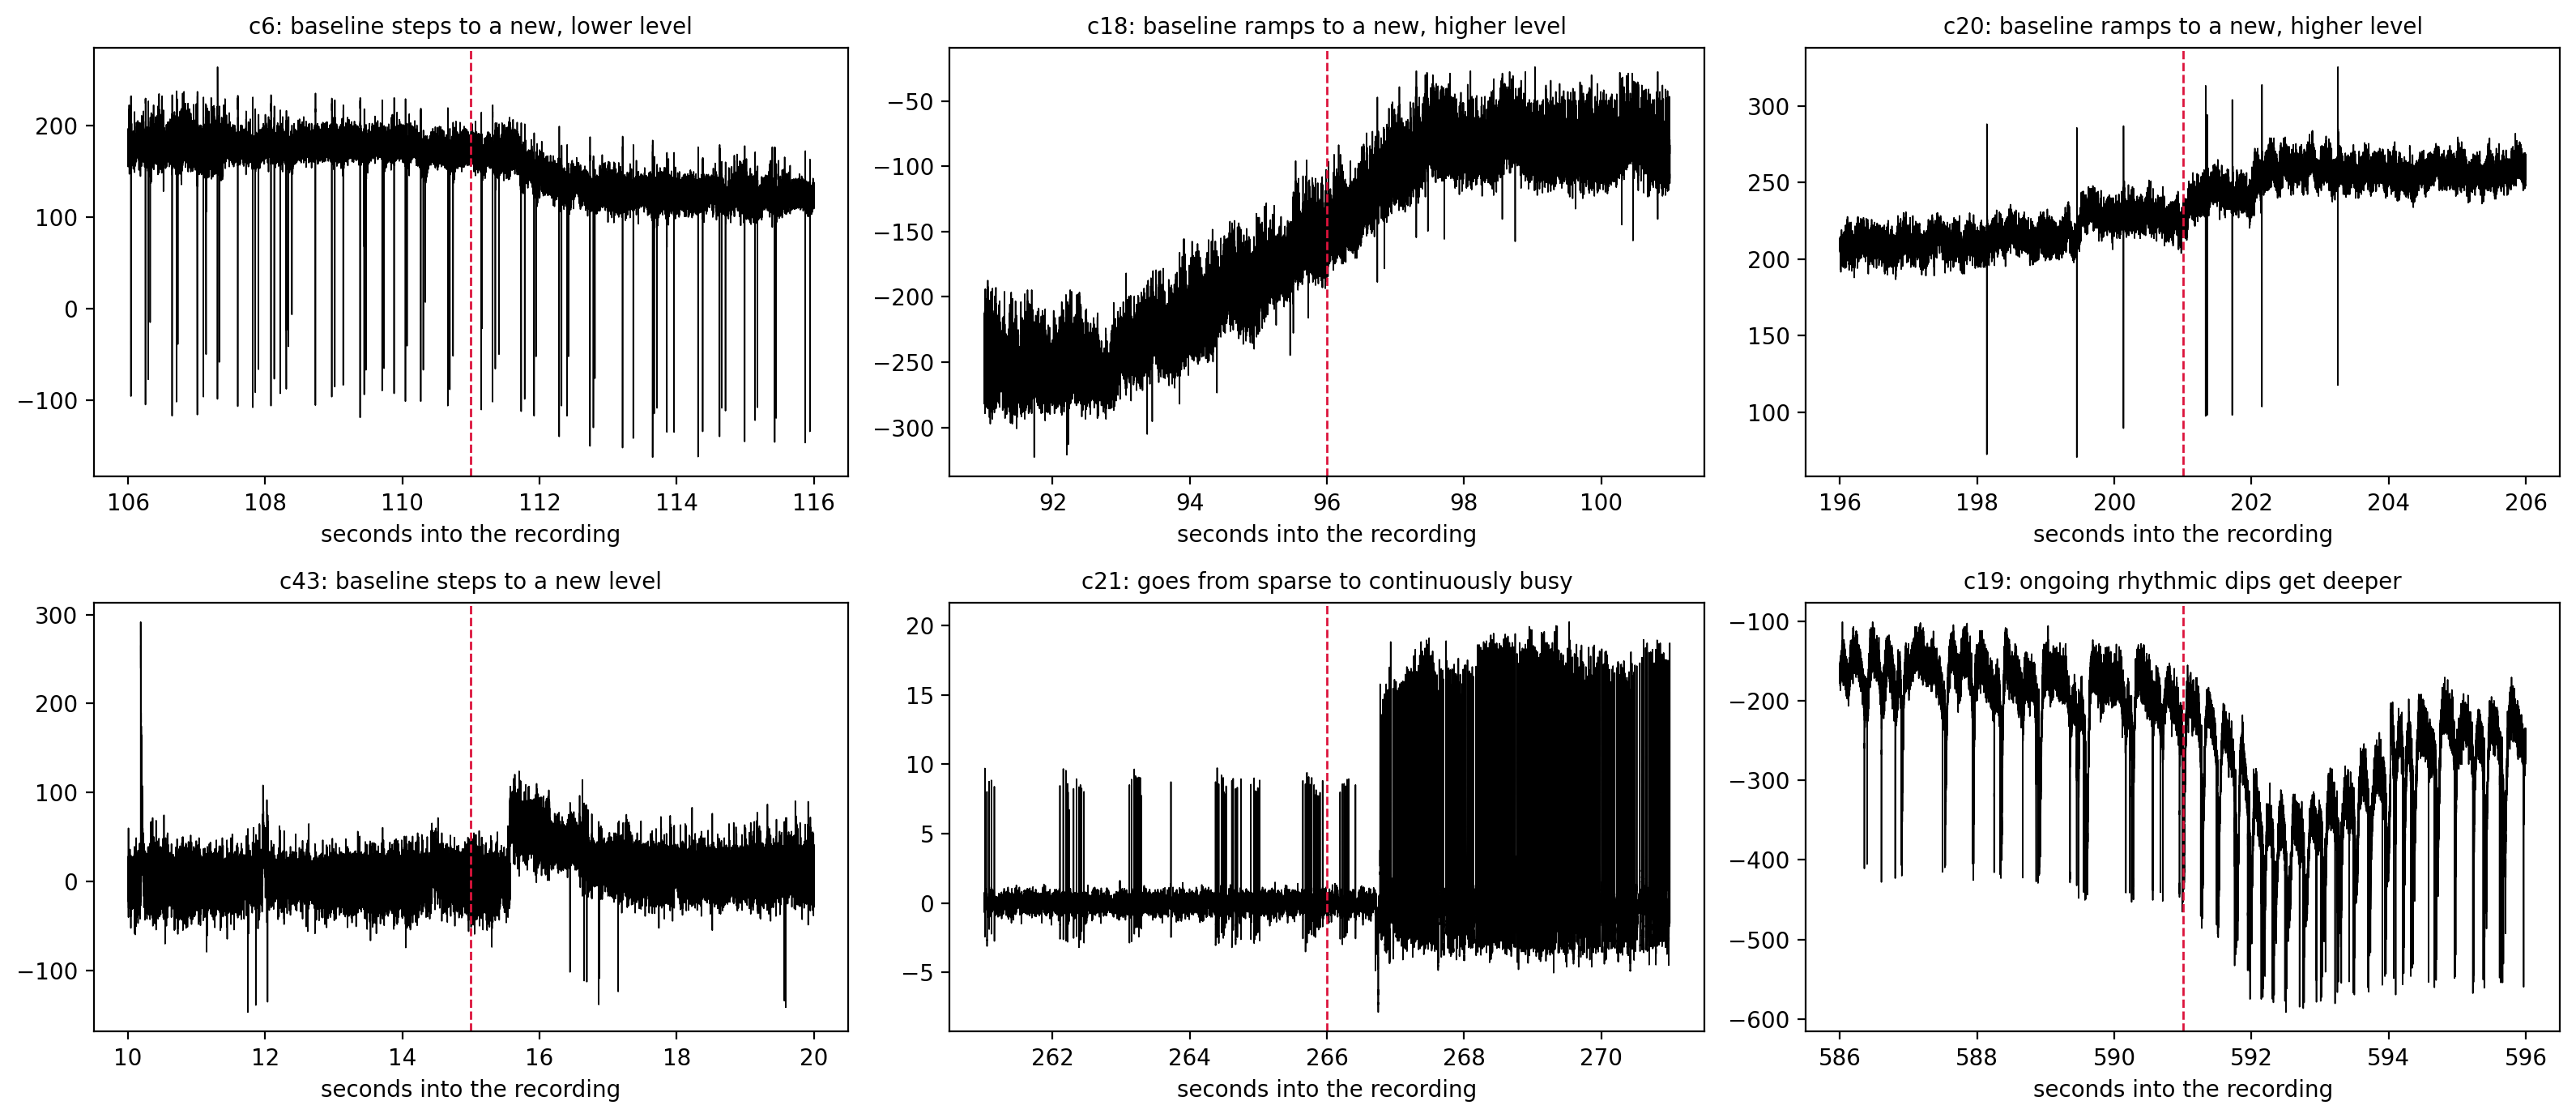

In [6]:
notable = [
    ('c6',  'baseline steps to a new, lower level'),
    ('c18', 'baseline ramps to a new, higher level'),
    ('c20', 'baseline ramps to a new, higher level'),
    ('c43', 'baseline steps to a new level'),
    ('c21', 'goes from sparse to continuously busy'),
    ('c19', 'ongoing rhythmic dips get deeper'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

for ax, (cid_str, description) in zip(axes, notable):
    cell_num = int(cid_str[1:])
    fs = config.DICT_PATCH_FS[cell_num]
    trace, _ = load_raw_patch(cell_num)
    row = jump_df[jump_df['cell_id'] == cid_str].iloc[0]
    t_center = row['jump_at_minute'] * 60
    i0 = max(0, int((t_center - 5) * fs))
    i1 = min(len(trace), int((t_center + 5) * fs))
    seg = trace[i0:i1]
    t = (np.arange(len(seg)) + i0) / fs
    ax.plot(t, seg, color='black', lw=0.6)
    ax.axvline(t_center, color='crimson', ls='--', lw=1)
    ax.set_title(f'{cid_str}: {description}', fontsize=10)
    ax.set_xlabel('seconds into the recording')

plt.tight_layout()
plt.show()

**Worth noting:** all six changes above happen very early - c43 at 15s, c18 at 96s, c6 at 111s, c20 at 201s, c21 at 266s, c19 at 591s (under 10 minutes into every recording, most under 5). That timing matches the settling-in period every patch recording has right after the electrode first seals onto the cell, not something occurring at an arbitrary point later in the recording, which is what a stimulus deliberately timed to rescue a quiet cell mid-recording would look like instead. Extending the check from each cell's single biggest jump to its top 3 didn't change this picture: none of the extra flagged jumps, in these 6 cells or any other, point to a distinct, later event.

### Cross-checking with a standard changepoint-detection method

The jump-ratio heuristic above is homemade. The field's actual tool for "did the mean level of this signal shift somewhere" is offline changepoint detection, PELT (Pruned Exact Linear Time) with an L2 cost and a BIC-style penalty is a standard, well-established choice. Run it on the same per-second baseline trace for every cell with a non-degenerate `typical_step`, independent of the heuristic above, and see whether it (a) finds a changepoint near the same time in the 6 cells already flagged as notable, and (b) stays quiet in the rest.

In [7]:
import ruptures as rpt

pelt_rows = []
for cell_num in cell_nums:
    t_min, baseline = baselines[cell_num]
    typical_step = np.median(np.abs(np.diff(baseline)))
    if typical_step < 1e-9:
        continue
    algo = rpt.Pelt(model='l2', min_size=5, jump=1).fit(baseline.reshape(-1, 1))
    pen = 3 * np.log(len(baseline)) * np.var(baseline)
    bkps = [b for b in algo.predict(pen=pen) if b < len(baseline)]
    pelt_rows.append({
        'cell_id': f'c{cell_num}',
        'n_changepoints': len(bkps),
        'changepoint_minutes': [round(t_min[b], 2) for b in bkps],
    })

pelt_df = pd.DataFrame(pelt_rows)
notable_ids = [cid for cid, _ in notable]

print(f'{(pelt_df["n_changepoints"] > 0).sum()} / {len(pelt_df)} cells get at least one PELT changepoint '
      f'at this penalty, PELT alone is not selective here, matching the pattern below is what matters.')
print()
print('The 6 heuristic-flagged cells, PELT changepoints vs. the heuristic jump time:')
for cid in notable_ids:
    heuristic_min = jump_df[jump_df['cell_id'] == cid].iloc[0]['jump_at_minute']
    pelt_mins = pelt_df[pelt_df['cell_id'] == cid]['changepoint_minutes'].iloc[0]
    nearest = min(pelt_mins, key=lambda m: abs(m - heuristic_min))
    print(f'{cid}: heuristic flagged {heuristic_min:.2f} min, nearest PELT changepoint {nearest:.2f} min '
          f'(all PELT changepoints: {pelt_mins})')

28 / 29 cells get at least one PELT changepoint at this penalty, PELT alone is not selective here, matching the pattern below is what matters.

The 6 heuristic-flagged cells, PELT changepoints vs. the heuristic jump time:
c6: heuristic flagged 1.85 min, nearest PELT changepoint 1.87 min (all PELT changepoints: [1.87, 2.27, 8.6, 18.18])
c18: heuristic flagged 1.60 min, nearest PELT changepoint 1.60 min (all PELT changepoints: [1.6, 8.4, 22.73])
c20: heuristic flagged 3.35 min, nearest PELT changepoint 3.30 min (all PELT changepoints: [1.18, 3.3])
c43: heuristic flagged 0.25 min, nearest PELT changepoint 0.25 min (all PELT changepoints: [0.25, 1.75])
c21: heuristic flagged 4.43 min, nearest PELT changepoint 4.45 min (all PELT changepoints: [4.45, 4.9, 5.37, 7.93, 8.27, 14.72])
c19: heuristic flagged 9.85 min, nearest PELT changepoint 4.72 min (all PELT changepoints: [0.58, 4.72])


**Result:** PELT lands within a minute of the heuristic's flagged time for 5 of the 6 notable cells (c6, c18, c20, c21, c43), an independent, formal method agreeing with the homemade one. For c19, PELT instead marks the start of the gradual dip-deepening trend rather than its single steepest second, a reasonable difference for a slow ramp rather than a sharp step, not a disagreement about whether something real happens there. At the same time, PELT also returns at least one changepoint for almost every other cell in the dataset, which is expected: a resting patch trace is never perfectly flat, and a formal method built to find *any* mean shift will find small, ordinary ones everywhere. So a bare "PELT found a changepoint" isn't on its own diagnostic of a stimulation artifact here, what makes the 6 flagged cells different is that their changepoint corresponds to a change large and sustained enough to see by eye, which is exactly the visual-confirmation step already used above, now with independent statistical backing for its timing rather than relying on the jump-ratio heuristic alone.

## 2. Zoom in on the raw trace for one cell

Set `CELL_TO_INSPECT` below and re-run - shows a few short raw-trace snippets spread across the recording (start / one-third / two-thirds / near the end), so you can look by eye for brief transient blips (Ashley's "tiny capacitance transients") anywhere in the trace, not just in the baseline summary above.

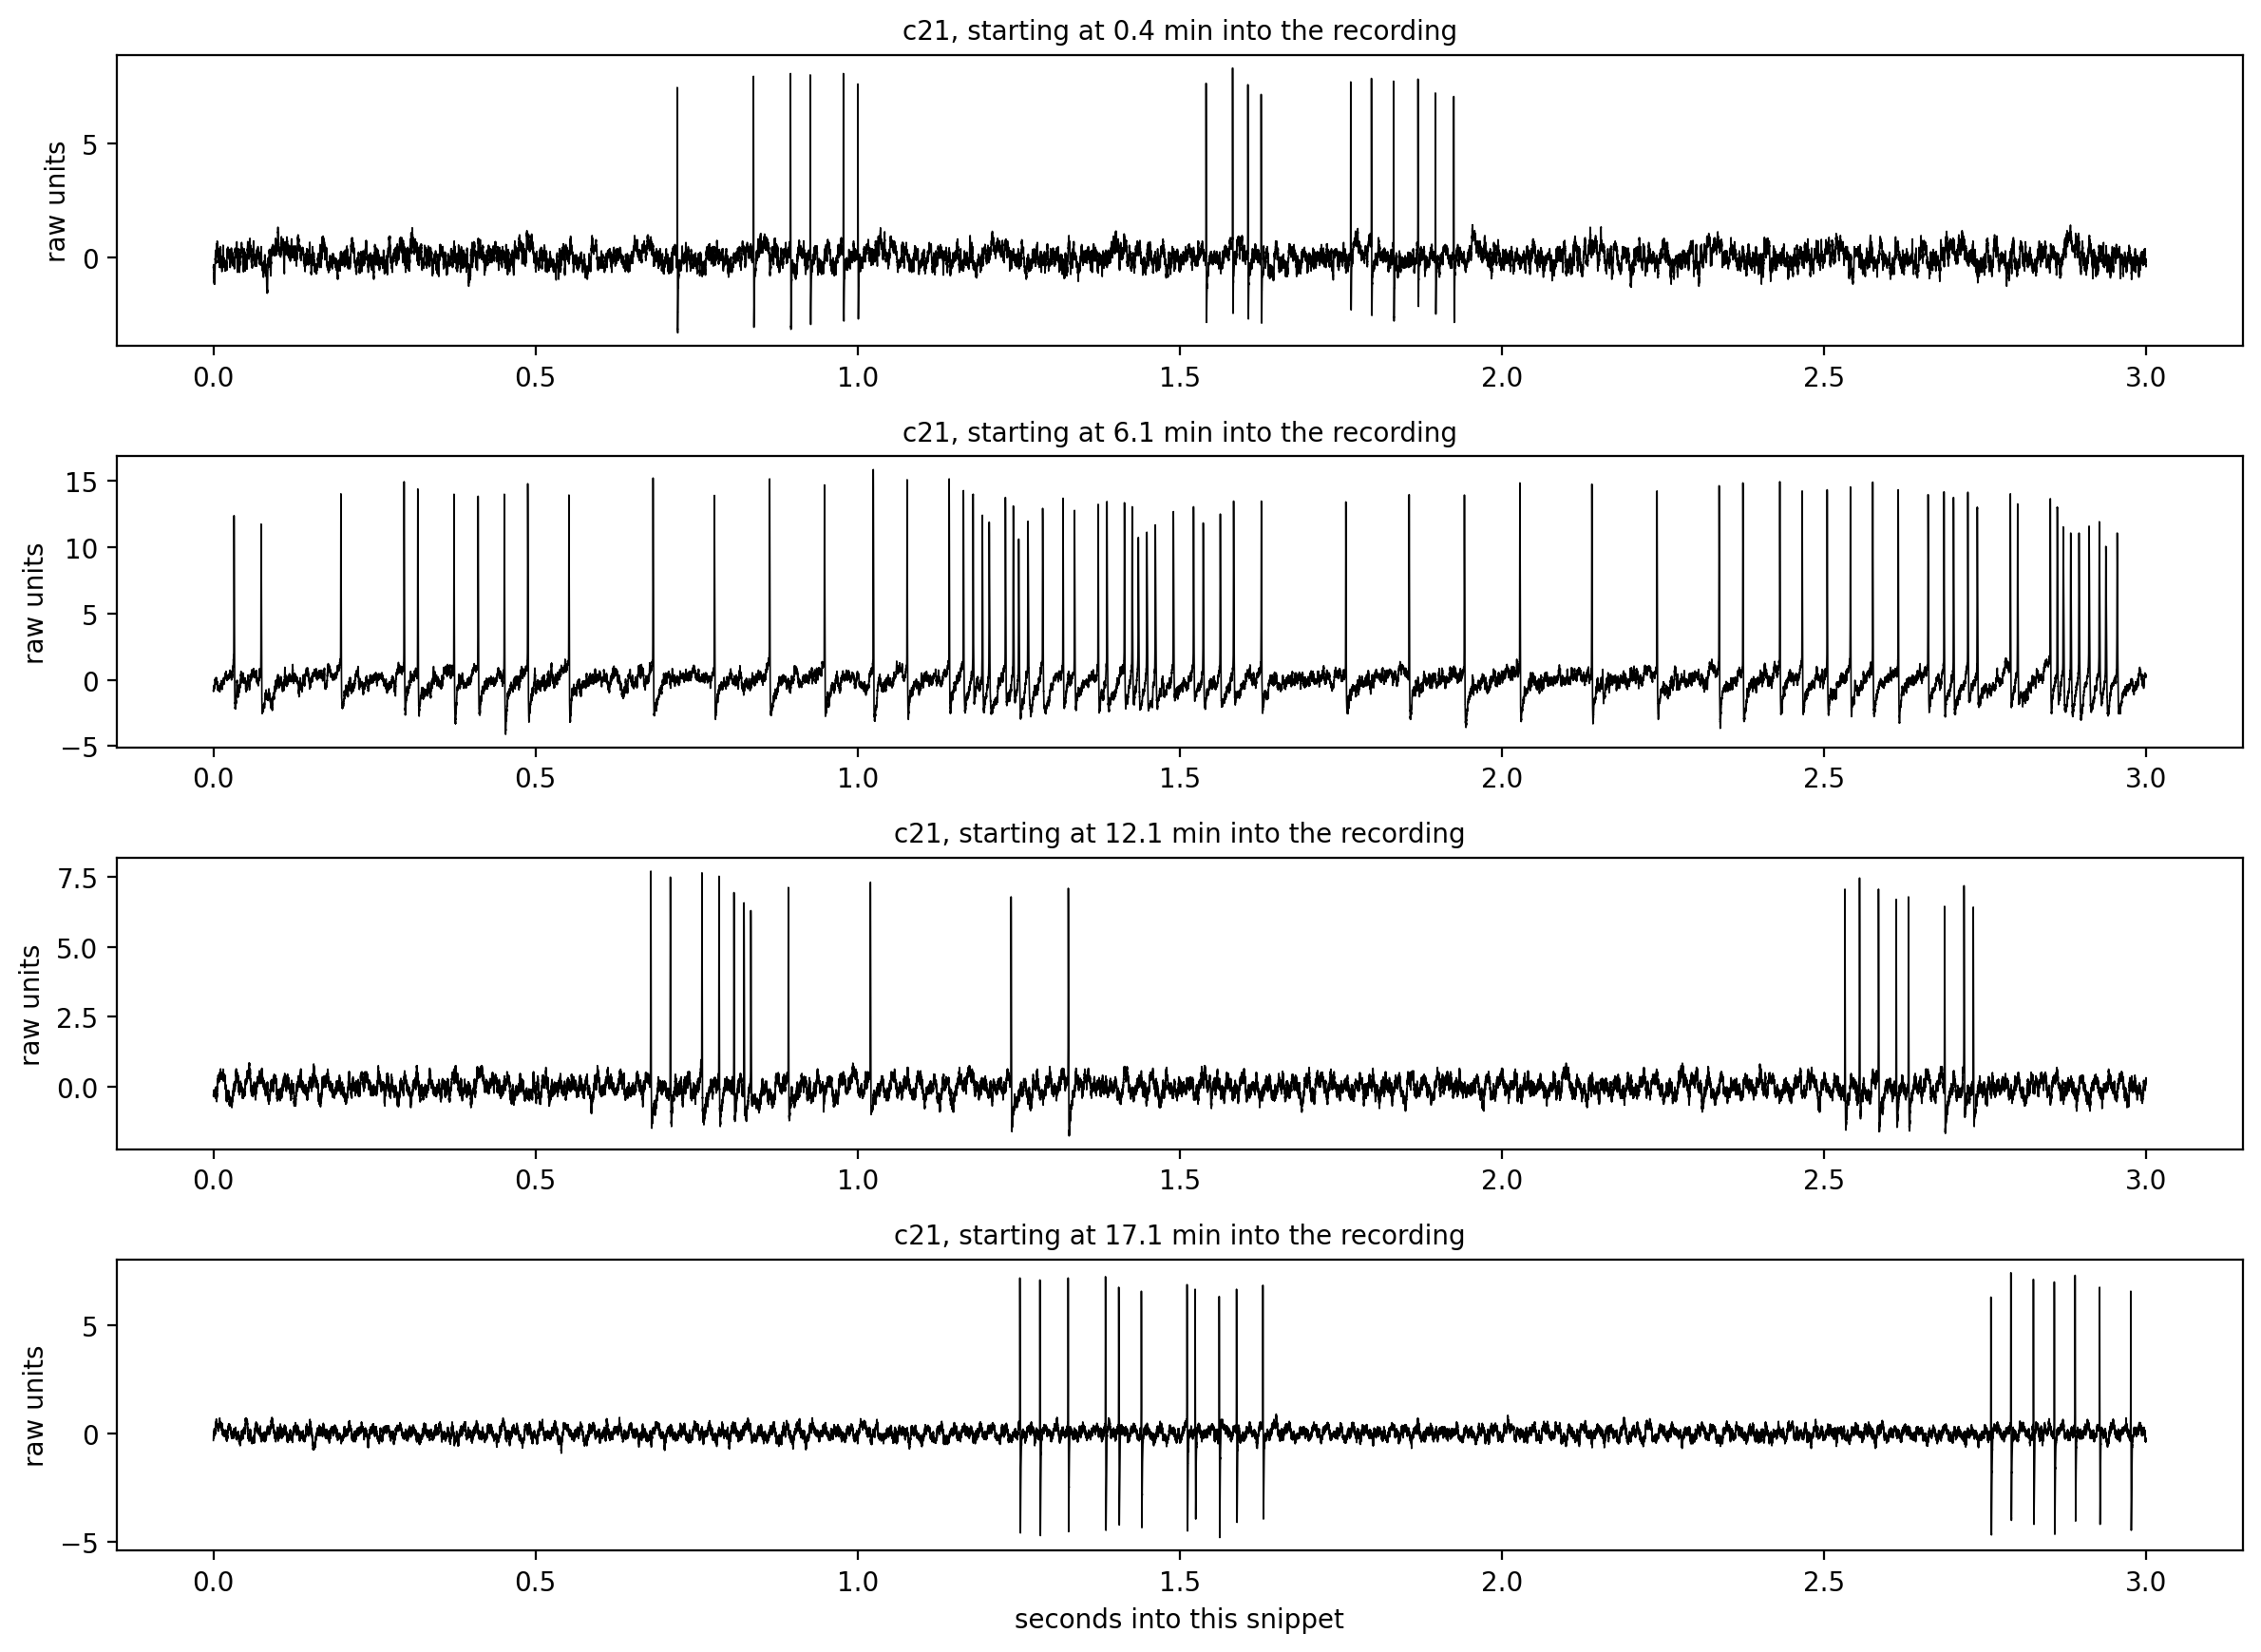

In [8]:
CELL_TO_INSPECT = 21   # change this to any cell number and re-run
SNIPPET_SECONDS = 3

trace, fs = load_raw_patch(CELL_TO_INSPECT)
duration_s = len(trace) / fs
snippet_starts = [duration_s * frac for frac in (0.02, 0.34, 0.67, 0.95)]

fig, axes = plt.subplots(len(snippet_starts), 1, figsize=(12, 2.2 * len(snippet_starts)), sharey=False)
for ax, t0 in zip(axes, snippet_starts):
    i0 = int(t0 * fs)
    i1 = i0 + int(SNIPPET_SECONDS * fs)
    seg = trace[i0:i1]
    t = np.arange(len(seg)) / fs
    ax.plot(t, seg, color='black', lw=0.6)
    ax.set_title(f'c{CELL_TO_INSPECT}, starting at {t0/60:.1f} min into the recording', fontsize=10)
    ax.set_ylabel('raw units')
axes[-1].set_xlabel('seconds into this snippet')
plt.tight_layout()
plt.show()

---
**Data used:** raw, unfiltered `c{N}_patch_ch1.bin` recordings for all 43 spe-1 cells, obtained from the lab's original recording archive and placed in `raw_patch_recordings/` alongside the existing `filt_patch_recordings/` used elsewhere in the pipeline. These are the true pre-processing recordings - no bandpass filter has been applied, so a real sustained shift in resting level would appear directly, rather than as the brief filtered echo a shift becomes after the 10 Hz highpass used everywhere else in the paper.

**How this compares to standard practice:** watching a cell's resting membrane potential for drift or a step is a completely standard patch-clamp QC habit, this notebook is just applying that habit here. The jump-ratio heuristic used above is homemade, so it's cross-checked against PELT, a standard formal changepoint-detection method, in the section above; the two agree closely on when the 6 real cases occur. The capacitance-transient scan (Part 2) is still more informal, it looks at a few arbitrary snippets rather than a window aligned to a known stimulus time, because unlike a routine bridge-balance check done live during an experiment, there's no known "when" to align to here, we're looking for evidence of a stimulus whose timing (if it happened at all) we don't know in advance. That's a limitation of the question being asked, not of the method.